# Gallbladder Disease Classification using Residual Attention CNN

## 1. Dataset Loading and Preprocessing

In [1]:
# ---------------------------------------------------------------------------------
# Imports, configuration, reproducibility
# ---------------------------------------------------------------------------------
import os
import math
import time
import copy
import random
import itertools
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score, precision_recall_curve)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
plt.rcParams["figure.dpi"] = 110

# ---- Configuration (mirrors the reference training recipe) -----------------------
DATA_DIR    = Path(r"D:\Assignment 1\Gallblader Diseases Dataset")
OUT_DIR     = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

IMG_SIZE    = 100          # images are resized to 100 x 100 (light + fast)
CHANNELS    = 3
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 0.001        # initial Adamax learning rate
LR_DECAY    = 0.1          # per-epoch exponential decay: lr <- lr * exp(-0.1)
RLROP_FACTOR   = 0.2       # ReduceLROnPlateau factor
RLROP_PATIENCE = 5         # ReduceLROnPlateau patience (epochs, monitors val loss)
MIN_LR      = 1e-4
L2_LAMBDA   = 1e-4         # L2 penalty on the two hidden dense layers
TRAIN_SIZE  = 0.80         # 80 / 10 / 10  train / validation / test
SEED        = 123

# Keep DataLoader single-process on Windows (multiprocessing hangs inside Jupyter)
NUM_WORKERS = 0 if os.name == "nt" else 4


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch :", torch.__version__)
print("Device  :", device)
if device.type == "cuda":
    print("GPU     :", torch.cuda.get_device_name(0))

PyTorch : 2.1.0+cu121
Device  : cuda
GPU     : NVIDIA GeForce GTX 1650


In [2]:
# ---------------------------------------------------------------------------------
# Index every image file into a dataframe (path -> label).
# Layout: DATA_DIR / <class folder> / *.jpg ; nested sub-folders are also supported.
# The folder names are prefixed with a digit ("1Gallstones"), so a clean display name
# is derived by stripping the leading number.
# ---------------------------------------------------------------------------------
IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR}"

image_paths, labels = [], []
for category in sorted(os.listdir(DATA_DIR)):
    cat_path = DATA_DIR / category
    if not cat_path.is_dir():
        continue
    subitems = os.listdir(cat_path)
    has_subdirs = any((cat_path / s).is_dir() for s in subitems)

    if has_subdirs:                       # nested: label comes from the sub-folder
        for sub in subitems:
            sub_path = cat_path / sub
            if not sub_path.is_dir():
                continue
            for fn in os.listdir(sub_path):
                if fn.lower().endswith(IMG_EXT):
                    image_paths.append(str(sub_path / fn)); labels.append(sub)
    else:                                 # flat: label is the category folder itself
        for fn in subitems:
            if fn.lower().endswith(IMG_EXT):
                image_paths.append(str(cat_path / fn)); labels.append(category)

data = pd.DataFrame({"image": image_paths, "label": labels})
assert len(data) > 0, "No images found - check DATA_DIR."

CLASSES      = sorted(data["label"].unique().tolist())
N_CLASSES    = len(CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
data["target"] = data["label"].map(class_to_idx)

# Readable names for plots: "1Gallstones" -> "Gallstones"
DISPLAY = [c.lstrip("0123456789 _-").strip().capitalize() if c[0].isdigit() else c for c in CLASSES]

print(f"Total images found: {len(data)}")
print(f"Number of classes : {N_CLASSES}\n")
print(data["label"].value_counts().to_string())
data.head()

Total images found: 10692
Number of classes : 9

label
8Carcinoma                                        1590
1Gallstones                                       1326
4Membranous and gangrenous cholecystitis          1224
2Abdomen and retroperitoneum                      1170
7Adenomyomatosis                                  1164
3cholecystitis                                    1146
5Perforation                                      1062
6Polyps and cholesterol crystals                  1020
9Various causes of gallbladder wall thickening     990


,image,label,target
0,D:\Assignment 1\Gallblader Diseases Dataset\1G...,1Gallstones,0
1,D:\Assignment 1\Gallblader Diseases Dataset\1G...,1Gallstones,0
2,D:\Assignment 1\Gallblader Diseases Dataset\1G...,1Gallstones,0
3,D:\Assignment 1\Gallblader Diseases Dataset\1G...,1Gallstones,0
4,D:\Assignment 1\Gallblader Diseases Dataset\1G...,1Gallstones,0


In [3]:
# ---------------------------------------------------------------------------------
# Leakage check BEFORE splitting.
#
# Ultrasound datasets are frequently built from multiple frames of the same clip /
# case. A plain random image-level split can then place near-duplicate frames of the
# same case in both train and test, letting the model "recognise" a case instead of
# learning generalisable features - this inflates test accuracy without meaning
# anything. Filenames are not a reliable way to detect this (naming conventions vary),
# so instead we fingerprint every image by its actual pixel content:
#   1. An exact MD5 hash catches byte-identical duplicate files.
#   2. A 256-bit average hash (16x16 grayscale, thresholded at the mean) catches
#      near-duplicate frames - resizes, re-saves, and near-identical consecutive
#      frames collapse to the same fingerprint, while genuinely different images do
#      not (a 256-bit fingerprint makes accidental collisions between unrelated
#      images extremely unlikely).
# Any images that share a fingerprint are treated as one indivisible group and are
# guaranteed to all end up in the SAME split.
# ---------------------------------------------------------------------------------
import hashlib

def md5_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def average_hash(path, hash_size=16):
    img = Image.open(path).convert("L").resize((hash_size, hash_size), Image.LANCZOS)
    arr = np.asarray(img, dtype=np.float32)
    bits = (arr > arr.mean()).flatten()
    return "".join("1" if b else "0" for b in bits)

print("Fingerprinting all images (exact + near-duplicate hash) ...")
data["md5"]   = data["image"].apply(md5_hash)
data["ahash"] = data["image"].apply(average_hash)

exact_dupes = data["md5"].duplicated(keep=False).sum()
group_sizes = data.groupby("ahash").size()
dup_groups  = group_sizes[group_sizes > 1]

print(f"Exact byte-identical duplicate files : {exact_dupes}")
print(f"Near-duplicate clusters (ahash)      : {len(dup_groups)} clusters "
      f"covering {int(dup_groups.sum())} images")
if len(dup_groups) > 0:
    print("These will each be kept together inside a single split (train, valid OR test),")
    print("so no near-duplicate frame can leak across the train/validation/test boundary.")
else:
    print("No near-duplicate clusters detected - the dataset appears to be one image per case.")

Fingerprinting all images (exact + near-duplicate hash) ...
Exact byte-identical duplicate files : 0
Near-duplicate clusters (ahash)      : 1300 clusters covering 2608 images
These will each be kept together inside a single split (train, valid OR test),
so no near-duplicate frame can leak across the train/validation/test boundary.


In [ ]:
# ---------------------------------------------------------------------------------
# Group-aware stratified split (80 / 10 / 10)
# ---------------------------------------------------------------------------------
group_label = (data.groupby("ahash")["label"]
                   .agg(lambda s: s.value_counts().idxmax())
                   .reset_index()
                   .rename(columns={"label": "majority_label"}))

train_groups, dummy_groups = train_test_split(
    group_label, train_size=TRAIN_SIZE, shuffle=True, random_state=SEED,
    stratify=group_label["majority_label"])

valid_groups, test_groups = train_test_split(
    dummy_groups, train_size=0.5, shuffle=True, random_state=SEED,
    stratify=dummy_groups["majority_label"])

train_ids = set(train_groups["ahash"]); valid_ids = set(valid_groups["ahash"]); test_ids = set(test_groups["ahash"])
assert not (train_ids & valid_ids) and not (train_ids & test_ids) and not (valid_ids & test_ids), \
    "Group overlap detected between splits - this should never happen."

train_df = data[data["ahash"].isin(train_ids)].drop(columns=["md5", "ahash"]).reset_index(drop=True)
valid_df = data[data["ahash"].isin(valid_ids)].drop(columns=["md5", "ahash"]).reset_index(drop=True)
test_df  = data[data["ahash"].isin(test_ids)].drop(columns=["md5", "ahash"]).reset_index(drop=True)

print(f"Training set  : {len(train_df)} images")
print(f"Validation set: {len(valid_df)} images")
print(f"Test set      : {len(test_df)} images\n")

split_table = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "valid": valid_df["label"].value_counts(),
    "test":  test_df["label"].value_counts(),
}).loc[CLASSES]
split_table["total"] = split_table.sum(axis=1)
split_table

Training set  : 8554 images
Validation set: 1067 images
Test set      : 1071 images



,train,valid,test,total
label,,,,
1Gallstones,1060,132,134,1326
2Abdomen and retroperitoneum,934,116,120,1170
3cholecystitis,917,114,115,1146
4Membranous and gangrenous cholecystitis,981,124,119,1224
5Perforation,848,106,108,1062
6Polyps and cholesterol crystals,819,101,100,1020
7Adenomyomatosis,931,116,117,1164
8Carcinoma,1271,159,160,1590
9Various causes of gallbladder wall thickening,793,99,98,990


In [ ]:
# ---------------------------------------------------------------------------------
# Preprocessing pipeline.
#   Resize to 100 x 100, keep RGB, and scale pixel values to [0, 1].
#   transforms.ToTensor() already performs the 1/255 rescaling, so it is the exact
#   PyTorch equivalent of ImageDataGenerator(rescale=1./255).
#   No augmentation is used - identical transforms for train, validation and test,
# ---------------------------------------------------------------------------------
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


class GallbladderDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.paths   = dataframe["image"].values
        self.targets = dataframe["target"].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.targets[idx])


train_ds = GallbladderDataset(train_df, tfm)
valid_ds = GallbladderDataset(valid_df, tfm)
test_ds  = GallbladderDataset(test_df,  tfm)

pin = (device.type == "cuda")
# drop_last=True protects BatchNorm from a final batch of size 1 (which would crash)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True)
train_eval_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=pin)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)

xb, yb = next(iter(train_loader))
print("Class indices:", class_to_idx)
print("\nBatch images :", tuple(xb.shape), xb.dtype)
print("Pixel range  : [%.3f, %.3f]" % (xb.min().item(), xb.max().item()))
print("Batch labels :", yb[:8].tolist())

Class indices: {'1Gallstones': 0, '2Abdomen and retroperitoneum': 1, '3cholecystitis': 2, '4Membranous and gangrenous cholecystitis': 3, '5Perforation': 4, '6Polyps and cholesterol crystals': 5, '7Adenomyomatosis': 6, '8Carcinoma': 7, '9Various causes of gallbladder wall thickening': 8}

Batch images : (32, 3, 100, 100) torch.float32
Pixel range  : [0.000, 0.996]
Batch labels : [3, 2, 6, 0, 7, 1, 5, 8]


## 2. Exploratory Data Analysis

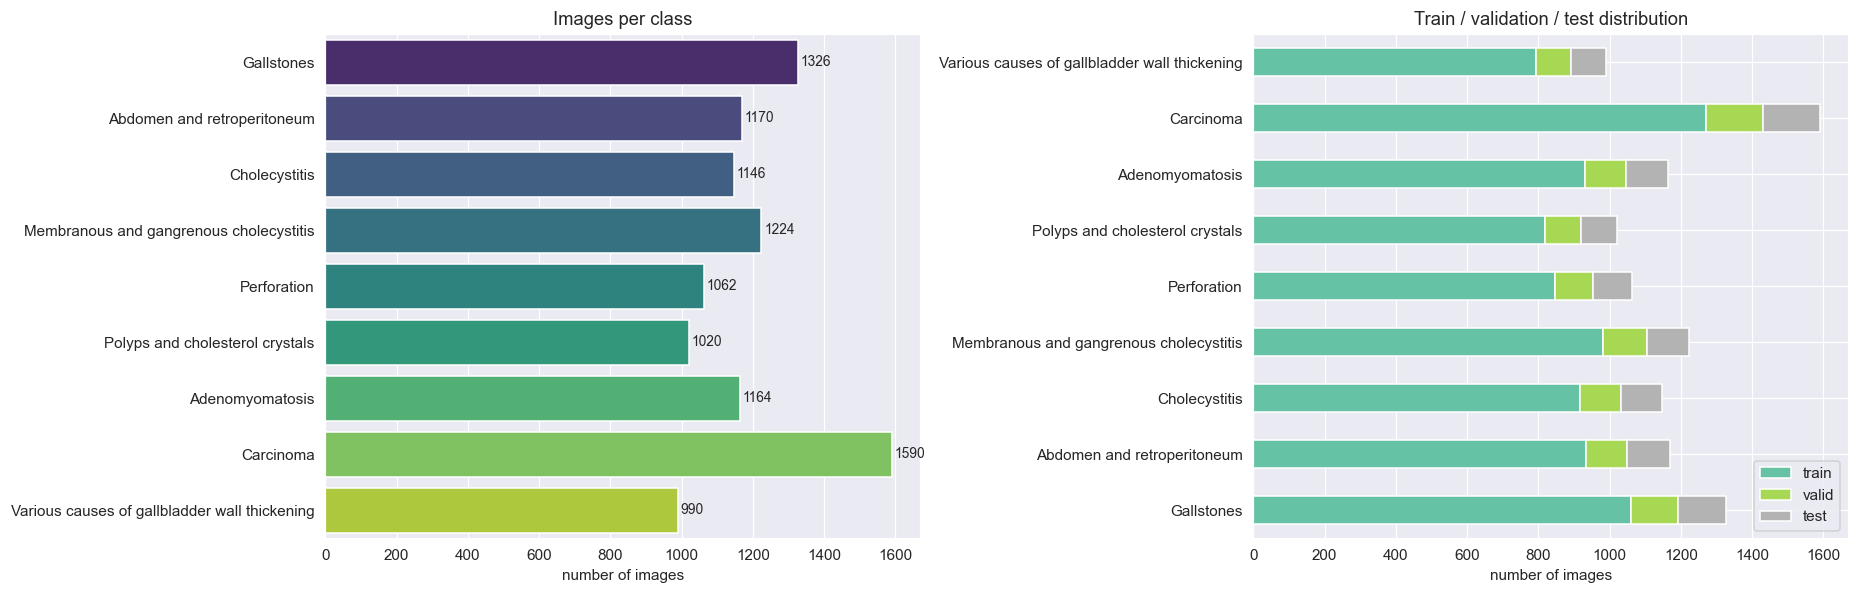

Imbalance ratio (largest / smallest class) = 1.61


In [8]:
# ---------------------------------------------------------------------------------
# Class distribution over the whole dataset and across the three splits
# ---------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

counts = data["label"].value_counts().loc[CLASSES]
sns.barplot(x=counts.values, y=DISPLAY, ax=axes[0], palette="viridis")
axes[0].set_title("Images per class")
axes[0].set_xlabel("number of images")
for i, v in enumerate(counts.values):
    axes[0].text(v + 8, i, str(v), va="center", fontsize=9)

tmp = split_table[["train", "valid", "test"]].copy()
tmp.index = DISPLAY
tmp.plot(kind="barh", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Train / validation / test distribution")
axes[1].set_xlabel("number of images")

plt.tight_layout(); plt.show()
print(f"Imbalance ratio (largest / smallest class) = {counts.max() / counts.min():.2f}")

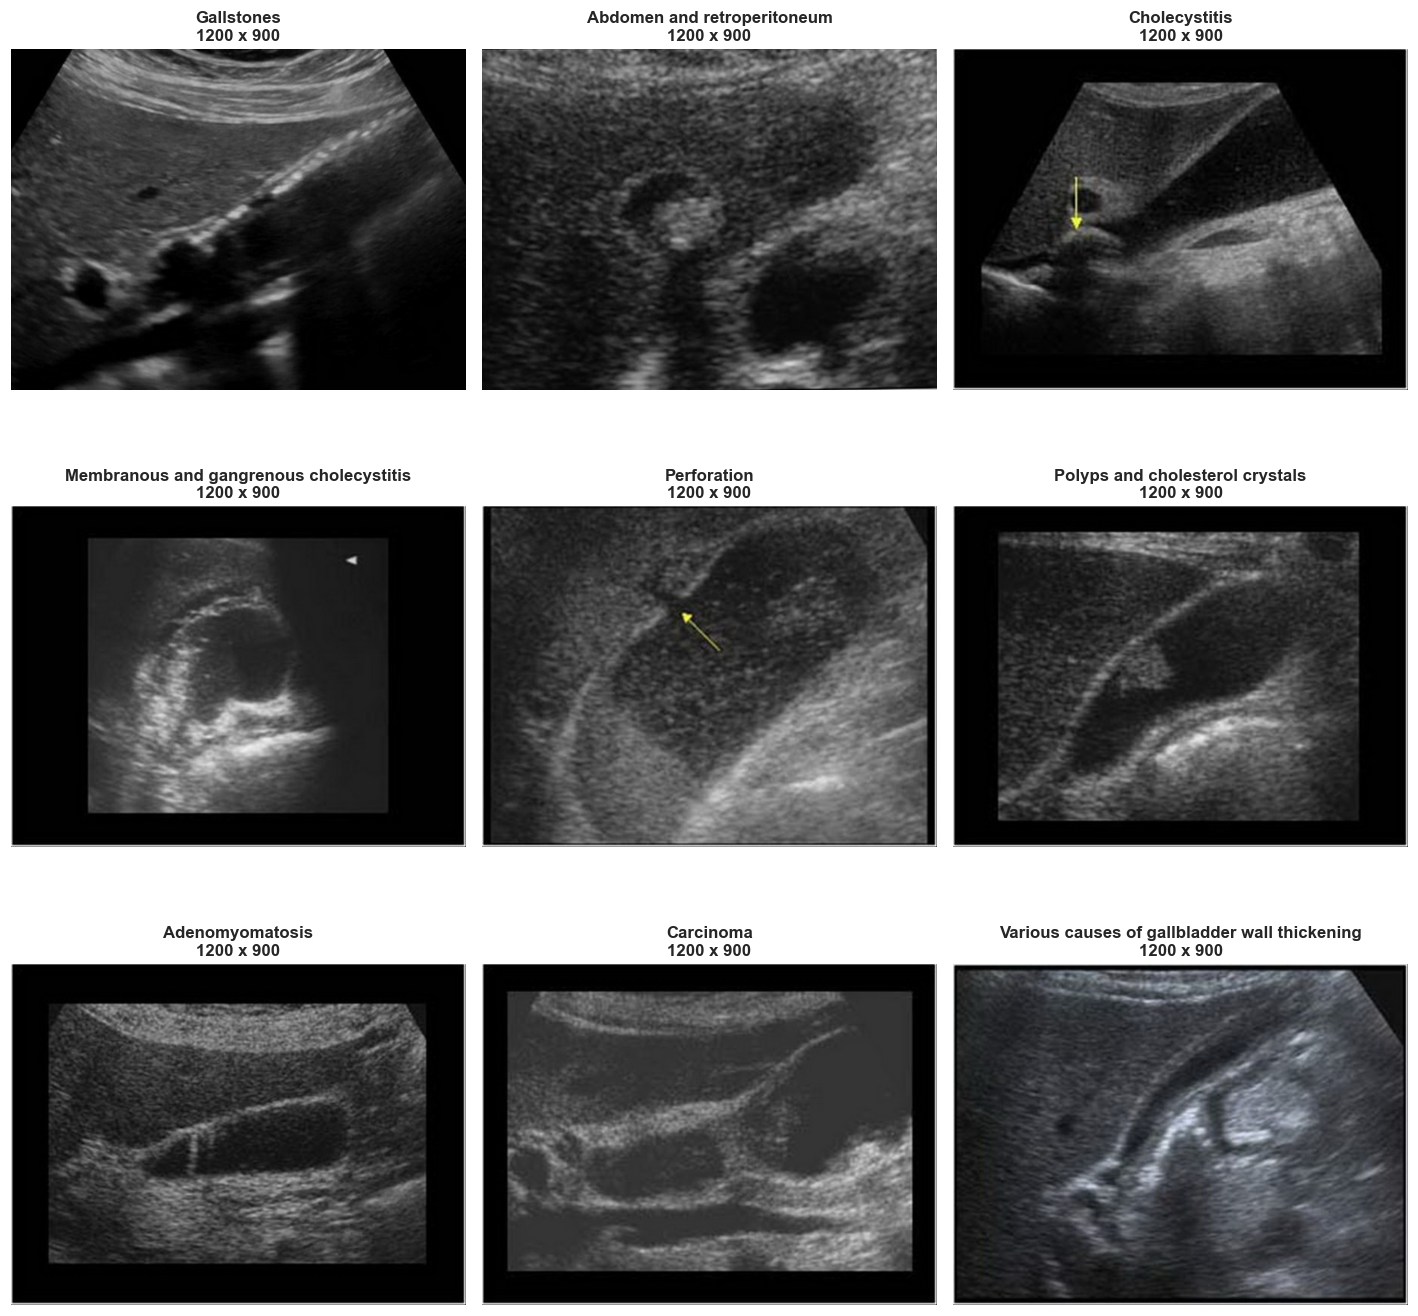

In [9]:
# ---------------------------------------------------------------------------------
# One sample image per class, straight from disk
# ---------------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes = axes.ravel()

for i, cls in enumerate(CLASSES):
    path = train_df[train_df["label"] == cls]["image"].values[0]
    img = Image.open(path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(f"{DISPLAY[i]}\n{img.size[0]} x {img.size[1]}", fontsize=11, fontweight="bold")
    axes[i].axis("off")

for j in range(N_CLASSES, len(axes)):
    axes[j].axis("off")

plt.tight_layout(); plt.show()

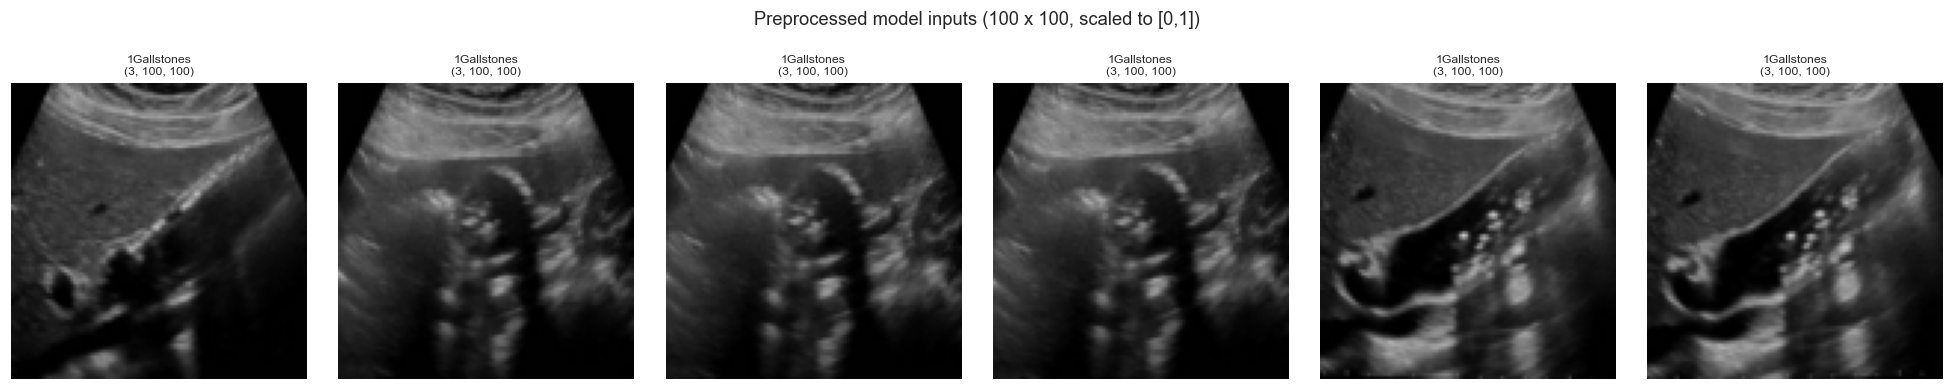

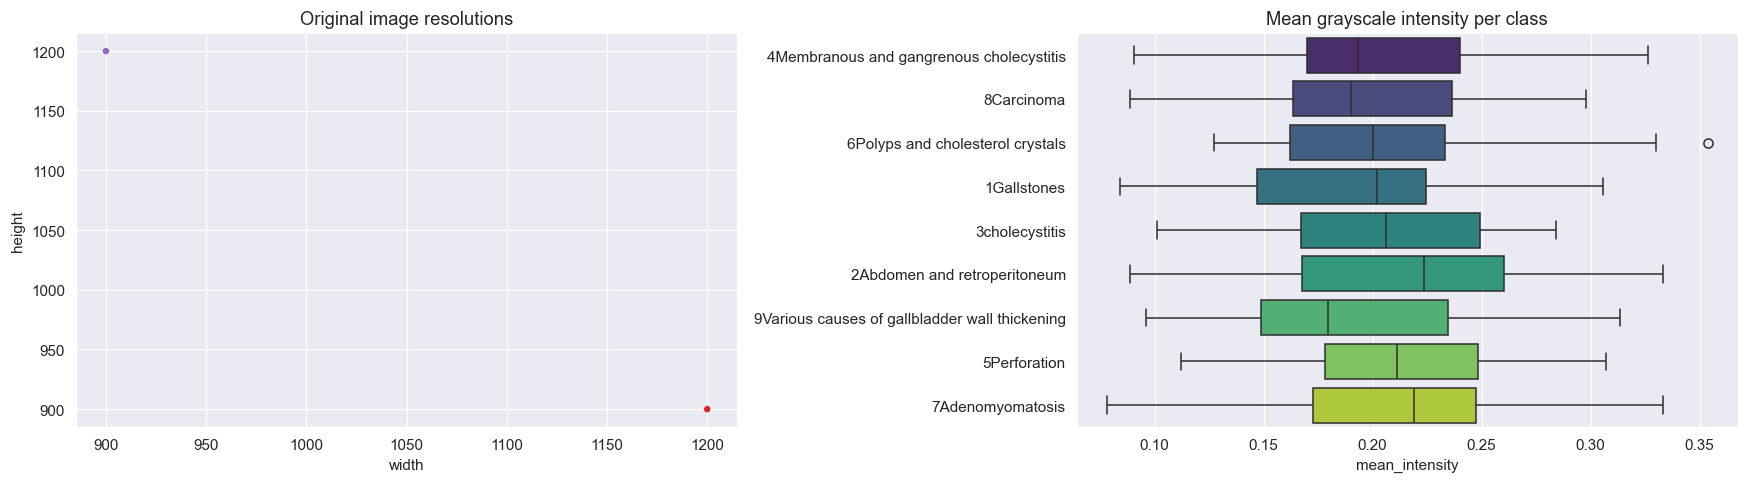

In [10]:
# ---------------------------------------------------------------------------------
# What the network actually sees: the same images after Resize(100, 100) + rescaling,
# plus basic image statistics on a random sample
# ---------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 6, figsize=(18, 3.3))
for ax, i in zip(axes, range(6)):
    t = tfm(Image.open(train_df["image"].iloc[i]).convert("RGB"))
    ax.imshow(t.permute(1, 2, 0).numpy())
    ax.set_title(f"{train_df['label'].iloc[i][:18]}\n{tuple(t.shape)}", fontsize=8)
    ax.axis("off")
plt.suptitle("Preprocessed model inputs (100 x 100, scaled to [0,1])", y=1.06)
plt.tight_layout(); plt.show()

sample = data.sample(min(500, len(data)), random_state=SEED)
rows = []
for _, r in sample.iterrows():
    with Image.open(r["image"]) as im:
        g = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        rows.append({"label": r["label"], "width": im.size[0], "height": im.size[1],
                     "mean_intensity": g.mean()})
stats = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.scatterplot(data=stats, x="width", y="height", hue="label", s=22, legend=False, ax=axes[0])
axes[0].set_title("Original image resolutions")
sns.boxplot(data=stats, x="mean_intensity", y="label", ax=axes[1], palette="viridis")
axes[1].set_title("Mean grayscale intensity per class"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

## 3. CNN Model Implementation

In [ ]:
# ---------------------------------------------------------------------------------
# Residual Attention CNN 
# ---------------------------------------------------------------------------------
class ChannelAttention(nn.Module):
    # Squeeze-and-excitation style gate built from avg-pool + max-pool descriptors
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Conv2d(channels, channels // reduction, 1, bias=False)  # == Dense(no bias)
        self.fc2 = nn.Conv2d(channels // reduction, channels, 1, bias=False)

    def forward(self, x):
        d = F.adaptive_avg_pool2d(x, 1) + F.adaptive_max_pool2d(x, 1)
        d = torch.sigmoid(self.fc2(F.relu(self.fc1(d))))
        return x * d


class ResidualAttentionBlock(nn.Module):
    # pre-activation residual pair + 1x1 projection shortcut + channel attention + pooling
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.short_conv = nn.Conv2d(in_ch, out_ch, 1, padding=0, bias=False)
        self.short_bn   = nn.BatchNorm2d(out_ch)

        self.bn_pre = nn.BatchNorm2d(in_ch)
        self.conv1  = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)

        self.attn = ChannelAttention(out_ch)
        self.pool = nn.MaxPool2d(2, 2)
        self.act  = nn.SiLU(inplace=True)     # swish

    def forward(self, x):
        shortcut = self.short_bn(self.short_conv(x))
        y = self.conv1(self.act(self.bn_pre(x)))
        y = self.conv2(self.act(self.bn1(y)))
        y = y + shortcut                       # residual connection
        y = self.attn(y)                       # channel attention gate
        return self.pool(y)


class ResidualAttentionCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, in_ch=CHANNELS):
        super().__init__()
        self.act = nn.SiLU(inplace=True)

        self.stem_conv = nn.Conv2d(in_ch, 32, 3, stride=2, padding=1, bias=False)
        self.stem_bn   = nn.BatchNorm2d(32)

        self.block1 = ResidualAttentionBlock(32,  64)
        self.block2 = ResidualAttentionBlock(64,  128)
        self.block3 = ResidualAttentionBlock(128, 256)

        self.bn_f1   = nn.BatchNorm2d(256)
        self.conv_f  = nn.Conv2d(256, 512, 3, padding=1, bias=False)
        self.bn_f2   = nn.BatchNorm2d(512)

        self.head_bn   = nn.BatchNorm1d(1024)   # 512 avg-pooled + 512 max-pooled
        self.head_drop = nn.Dropout(0.3)

        self.fc1    = nn.Linear(1024, 256)      # L2-regularised (see L2_LAMBDA)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.drop1  = nn.Dropout(0.4)

        self.fc2    = nn.Linear(256, 128)       # L2-regularised
        self.bn_fc2 = nn.BatchNorm1d(128)
        self.drop2  = nn.Dropout(0.3)

        self.out = nn.Linear(128, n_classes)    # logits (softmax is inside the loss)
        self._init_weights()

    def _init_weights(self):
        # Glorot/Xavier uniform, matching the Keras default initialiser
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if getattr(m, "bias", None) is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def features(self, x):
        x = self.act(self.stem_bn(self.stem_conv(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.act(self.bn_f1(x))
        x = self.act(self.bn_f2(self.conv_f(x)))
        return x

    def forward(self, x):
        x = self.features(x)
        gap = F.adaptive_avg_pool2d(x, 1).flatten(1)
        gmp = F.adaptive_max_pool2d(x, 1).flatten(1)
        x = torch.cat([gap, gmp], dim=1)

        x = self.head_drop(self.head_bn(x))
        x = self.drop1(self.bn_fc1(self.act(self.fc1(x))))
        x = self.drop2(self.bn_fc2(self.act(self.fc2(x))))
        return self.out(x)


model = ResidualAttentionCNN().to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}\n")

# Layer-wise output shapes
x = torch.zeros(2, CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
model.eval()
with torch.no_grad():
    print(f"{'stage':<26}{'output shape':<24}{'params':>12}")
    print("-" * 62)
    print(f"{'input':<26}{str(tuple(x.shape)):<24}{0:>12,}")
    x = model.act(model.stem_bn(model.stem_conv(x)))
    print(f"{'stem (stride-2 conv)':<26}{str(tuple(x.shape)):<24}"
          f"{sum(p.numel() for p in [model.stem_conv.weight, *model.stem_bn.parameters()]):>12,}")
    for name, blk in [("block1 (64)", model.block1), ("block2 (128)", model.block2),
                      ("block3 (256)", model.block3)]:
        x = blk(x)
        print(f"{name:<26}{str(tuple(x.shape)):<24}{sum(p.numel() for p in blk.parameters()):>12,}")
    x = model.act(model.bn_f1(x)); x = model.act(model.bn_f2(model.conv_f(x)))
    print(f"{'final conv (512)':<26}{str(tuple(x.shape)):<24}"
          f"{model.conv_f.weight.numel() + sum(p.numel() for p in model.bn_f2.parameters()):>12,}")
    print(f"{'concat[GAP, GMP]':<26}{str((x.shape[0], 1024)):<24}{0:>12,}")
    head = [model.head_bn, model.fc1, model.bn_fc1, model.fc2, model.bn_fc2, model.out]
    print(f"{'classifier head':<26}{str((x.shape[0], N_CLASSES)):<24}"
          f"{sum(p.numel() for m in head for p in m.parameters()):>12,}")
    print("-" * 62)
model.train()
print(model)

Trainable parameters: 2,709,353

stage                     output shape                  params
--------------------------------------------------------------
input                     (2, 3, 100, 100)                   0
stem (stride-2 conv)      (2, 32, 50, 50)                  928
block1 (64)               (2, 64, 25, 25)               58,688
block2 (128)              (2, 128, 12, 12)             234,112
block3 (256)              (2, 256, 6, 6)               935,168
final conv (512)          (2, 512, 6, 6)             1,180,672
concat[GAP, GMP]          (2, 1024)                          0
classifier head           (2, 9)                       299,273
--------------------------------------------------------------
ResidualAttentionCNN(
  (act): SiLU(inplace=True)
  (stem_conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): ResidualAttentionBlock(
   

## 4. Model Training

In [12]:
# ---------------------------------------------------------------------------------
# Training setup (same recipe as the reference notebook):
#   Optimiser  : Adamax, initial lr = 0.001
#   Loss       : categorical cross-entropy  == nn.CrossEntropyLoss on raw logits
#   L2         : 1e-4 penalty on the two hidden dense layers, added to the loss
#                (the PyTorch equivalent of Keras kernel_regularizer=l2(1e-4))
#   Epochs     : 20, batch size 32
#   Schedules  : (a) exponential decay every epoch  lr <- lr * exp(-0.1)
#                (b) ReduceLROnPlateau on val_loss (factor 0.2, patience 5, min 1e-4)
#   Monitor    : prints train / validation accuracy each epoch and flags 99% accuracy
# ---------------------------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adamax(model.parameters(), lr=LR)


def l2_penalty(model):
    # Keras l2(lambda) adds lambda * sum(w^2) to the loss for the given kernels
    return L2_LAMBDA * (model.fc1.weight.pow(2).sum() + model.fc2.weight.pow(2).sum())


def set_lr(optimizer, lr):
    for g in optimizer.param_groups:
        g["lr"] = lr


def run_epoch(model, loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(train_mode):
        for images, targets in loader:
            images  = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, targets)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                (loss + l2_penalty(model)).backward()
                optimizer.step()

            bs = images.size(0)
            total_loss += loss.item() * bs
            correct    += (outputs.argmax(1) == targets).sum().item()
            n          += bs

    return total_loss / n, correct / n


@torch.no_grad()
def predict_probs(model, loader):
    # returns softmax probabilities and the true labels, in loader order
    model.eval()
    probs, trues = [], []
    for images, targets in loader:
        out = model(images.to(device, non_blocking=True))
        probs.append(torch.softmax(out, dim=1).cpu())
        trues.append(targets)
    return torch.cat(probs).numpy(), torch.cat(trues).numpy()

In [13]:
# ---------------------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------------------
history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": [], "lr": []}

current_lr   = LR
best_val_loss, plateau_wait = float("inf"), 0
best_val_acc, best_epoch = -1.0, -1
best_weights = copy.deepcopy(model.state_dict())
ckpt_path = OUT_DIR / "best_model.pt"

t_start = time.time()
for epoch in range(EPOCHS):
    # --- (a) LearningRateScheduler: exponential decay applied at the start of the epoch
    current_lr = current_lr * math.exp(-LR_DECAY)
    set_lr(optimizer, current_lr)

    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, train_mode=True)
    va_loss, va_acc = run_epoch(model, valid_loader, train_mode=False)

    history["loss"].append(tr_loss);         history["accuracy"].append(tr_acc)
    history["val_loss"].append(va_loss);     history["val_accuracy"].append(va_acc)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch + 1}/{EPOCHS} - {time.time() - t0:.0f}s - "
          f"loss: {tr_loss:.4f} - accuracy: {tr_acc:.4f} - "
          f"val_loss: {va_loss:.4f} - val_accuracy: {va_acc:.4f} - lr: {current_lr:.2e}")

    # --- keep the best weights (by validation accuracy)
    if va_acc > best_val_acc:
        best_val_acc, best_epoch = va_acc, epoch + 1
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, ckpt_path)

    # --- (b) ReduceLROnPlateau on validation loss, applied at the end of the epoch
    if va_loss < best_val_loss - 1e-4:
        best_val_loss, plateau_wait = va_loss, 0
    else:
        plateau_wait += 1
        if plateau_wait >= RLROP_PATIENCE:
            new_lr = max(current_lr * RLROP_FACTOR, MIN_LR)
            if new_lr < current_lr:
                print(f"   ReduceLROnPlateau: lr {current_lr:.2e} -> {new_lr:.2e}")
                current_lr, plateau_wait = new_lr, 0

print("-" * 78)
print(f"Training finished in {(time.time() - t_start) / 60:.1f} min")
print(f"Best validation accuracy: {best_val_acc:.4f} (epoch {best_epoch})")

# Set to True to evaluate the best checkpoint instead of the final-epoch weights
RESTORE_BEST = False
if RESTORE_BEST:
    model.load_state_dict(best_weights)
    print("Restored best-epoch weights for evaluation.")

hist_df = pd.DataFrame(history); hist_df.index = np.arange(1, len(hist_df) + 1)
hist_df.index.name = "epoch"
hist_df.to_csv(OUT_DIR / "training_history.csv")
hist_df.tail()

Epoch 1/20 - 75s - loss: 2.4432 - accuracy: 0.2286 - val_loss: 1.8962 - val_accuracy: 0.3561 - lr: 9.05e-04
Epoch 2/20 - 77s - loss: 1.9035 - accuracy: 0.3591 - val_loss: 1.4210 - val_accuracy: 0.5258 - lr: 8.19e-04
Epoch 3/20 - 76s - loss: 1.4612 - accuracy: 0.5022 - val_loss: 1.0497 - val_accuracy: 0.6354 - lr: 7.41e-04
Epoch 4/20 - 75s - loss: 0.9984 - accuracy: 0.6603 - val_loss: 0.7398 - val_accuracy: 0.7441 - lr: 6.70e-04
Epoch 5/20 - 76s - loss: 0.6325 - accuracy: 0.7925 - val_loss: 0.5814 - val_accuracy: 0.7985 - lr: 6.07e-04
Epoch 6/20 - 75s - loss: 0.3612 - accuracy: 0.8874 - val_loss: 0.3282 - val_accuracy: 0.8950 - lr: 5.49e-04
Epoch 7/20 - 76s - loss: 0.2332 - accuracy: 0.9294 - val_loss: 0.2235 - val_accuracy: 0.9335 - lr: 4.97e-04
Epoch 8/20 - 76s - loss: 0.1209 - accuracy: 0.9682 - val_loss: 0.1801 - val_accuracy: 0.9400 - lr: 4.49e-04
Epoch 9/20 - 76s - loss: 0.0919 - accuracy: 0.9767 - val_loss: 0.1375 - val_accuracy: 0.9597 - lr: 4.07e-04
Epoch 10/20 - 76s - loss: 0.

,loss,accuracy,val_loss,val_accuracy,lr
epoch,,,,,
16,0.018166,0.997425,0.069636,0.978444,0.000202
17,0.020355,0.996372,0.086626,0.971884,0.000183
18,0.018577,0.995435,0.078177,0.978444,0.000165
19,0.015615,0.997308,0.075806,0.980319,0.000150
20,0.010547,0.998713,0.069957,0.980319,0.000135


## 5. Model Evaluation

In [14]:
# ---------------------------------------------------------------------------------
# Loss and accuracy on all three subsets
# ---------------------------------------------------------------------------------
train_loss, train_acc = run_epoch(model, train_eval_loader, train_mode=False)
valid_loss, valid_acc = run_epoch(model, valid_loader, train_mode=False)
test_loss,  test_acc  = run_epoch(model, test_loader,  train_mode=False)

print(f"Train Loss    : {train_loss:.4f}")
print(f"Train Accuracy: {train_acc:.4f}")
print("-" * 30)
print(f"Valid Loss    : {valid_loss:.4f}")
print(f"Valid Accuracy: {valid_acc:.4f}")
print("-" * 30)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Train Loss    : 0.0006
Train Accuracy: 0.9999
------------------------------
Valid Loss    : 0.0700
Valid Accuracy: 0.9803
------------------------------
Test Loss     : 0.0688
Test Accuracy : 0.9785


In [15]:
# ---------------------------------------------------------------------------------
# Classification report on the test set
# ---------------------------------------------------------------------------------
test_probs, y_true = predict_probs(model, test_loader)
y_pred = test_probs.argmax(axis=1)

print("CLASSIFICATION REPORT (test set)\n")
print(classification_report(y_true, y_pred, target_names=DISPLAY, digits=4, zero_division=0))

report = classification_report(y_true, y_pred, target_names=DISPLAY,
                               output_dict=True, zero_division=0)
pd.DataFrame(report).T.round(4)

CLASSIFICATION REPORT (test set)

                                               precision    recall  f1-score   support

                                   Gallstones     0.9635    0.9851    0.9742       134
                  Abdomen and retroperitoneum     0.9836    1.0000    0.9917       120
                                Cholecystitis     0.9744    0.9913    0.9828       115
      Membranous and gangrenous cholecystitis     0.9754    1.0000    0.9876       119
                                  Perforation     1.0000    0.9907    0.9953       108
              Polyps and cholesterol crystals     0.9897    0.9600    0.9746       100
                              Adenomyomatosis     0.9512    1.0000    0.9750       117
                                    Carcinoma     0.9933    0.9250    0.9579       160
Various causes of gallbladder wall thickening     0.9794    0.9694    0.9744        98

                                     accuracy                         0.9785      1071
       

,precision,recall,f1-score,support
Gallstones,0.9635,0.9851,0.9742,134.0000
Abdomen and retroperitoneum,0.9836,1.0000,0.9917,120.0000
Cholecystitis,0.9744,0.9913,0.9828,115.0000
Membranous and gangrenous cholecystitis,0.9754,1.0000,0.9876,119.0000
Perforation,1.0000,0.9907,0.9953,108.0000
Polyps and cholesterol crystals,0.9897,0.9600,0.9746,100.0000
Adenomyomatosis,0.9512,1.0000,0.9750,117.0000
Carcinoma,0.9933,0.9250,0.9579,160.0000
Various causes of gallbladder wall thickening,0.9794,0.9694,0.9744,98.0000
accuracy,0.9785,0.9785,0.9785,0.9785


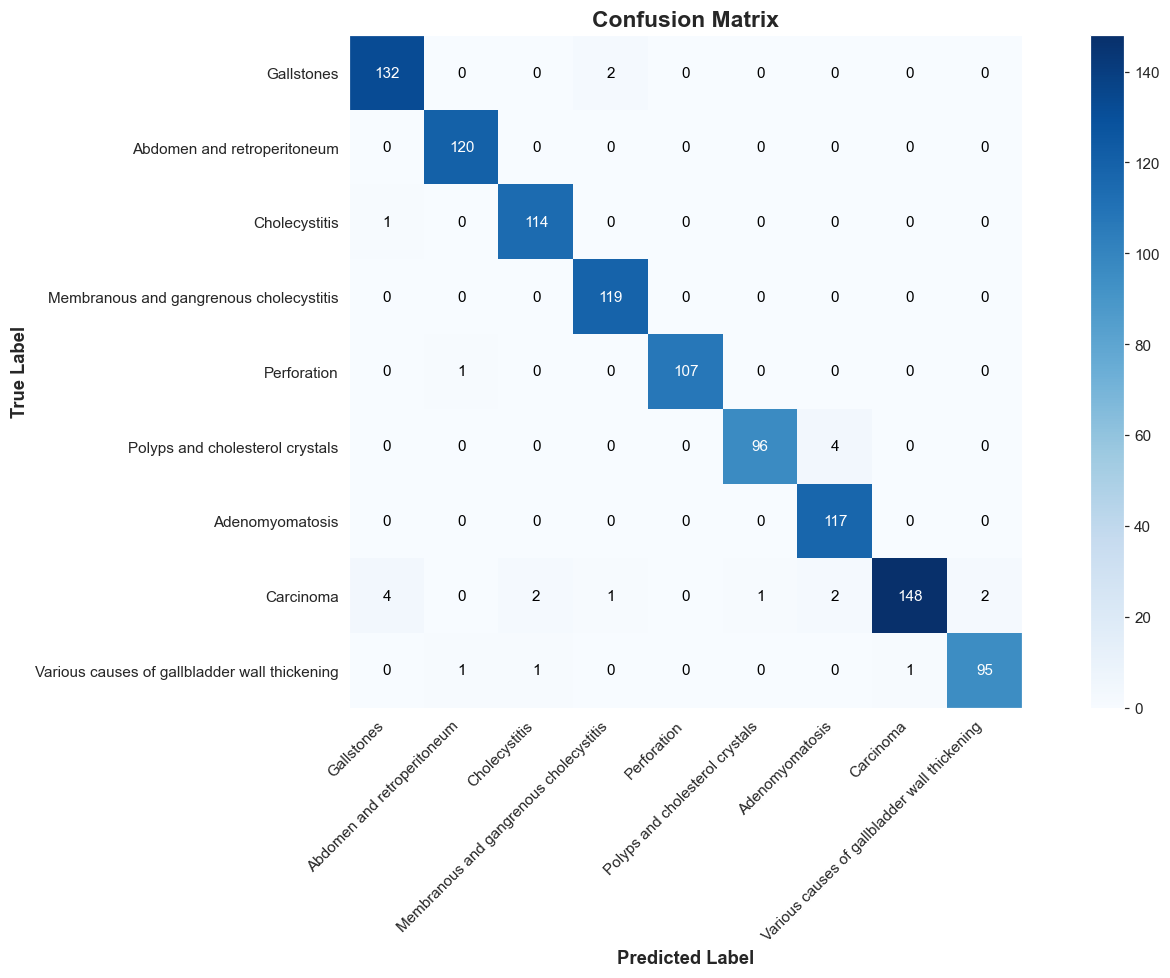

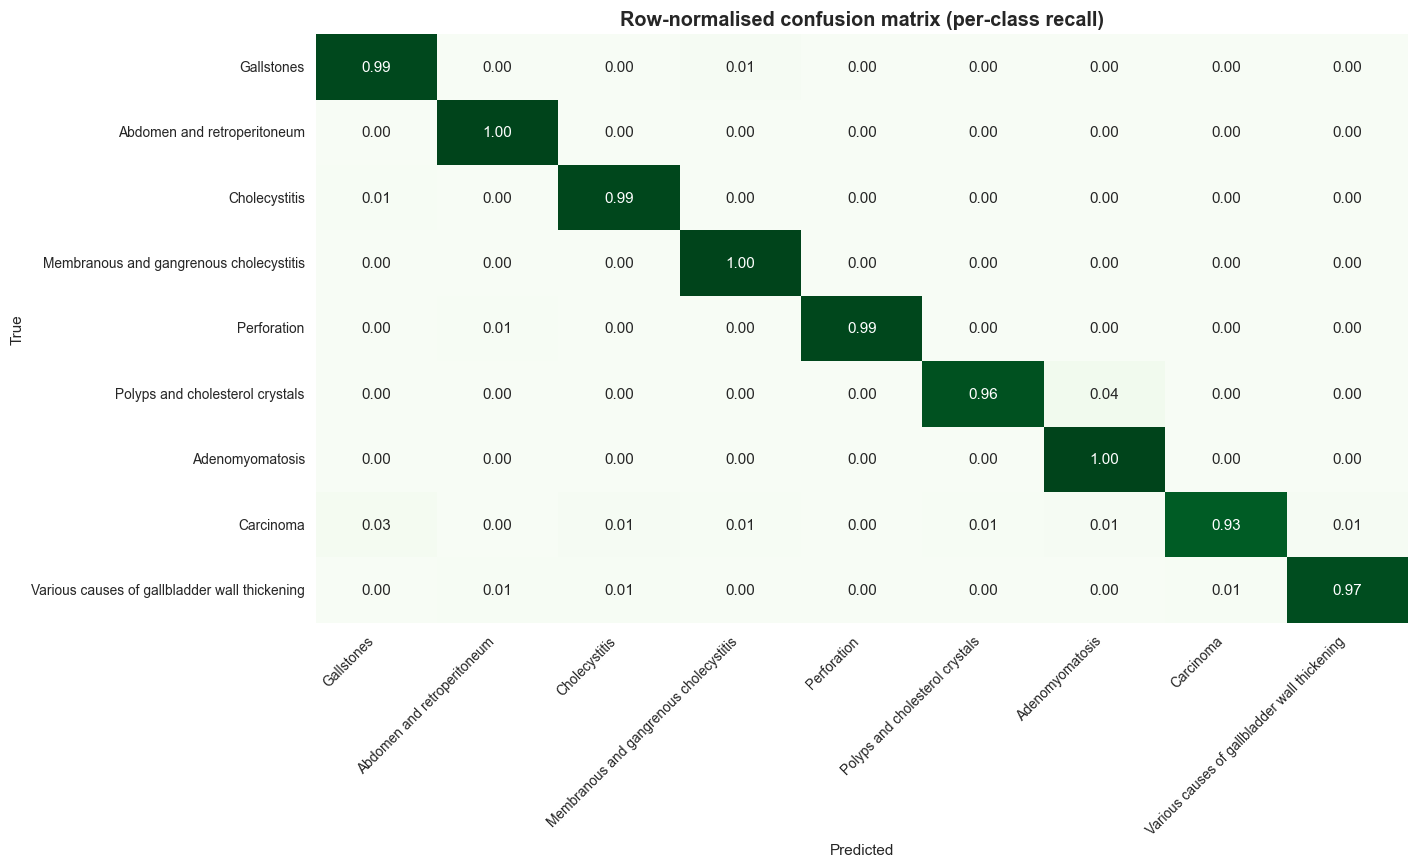

In [16]:
# ---------------------------------------------------------------------------------
# Confusion matrix (counts and row-normalised recall)
# ---------------------------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 9))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix", fontsize=15, fontweight="bold")
plt.colorbar()
ticks = np.arange(N_CLASSES)
plt.xticks(ticks, DISPLAY, rotation=45, ha="right")
plt.yticks(ticks, DISPLAY)
plt.grid(False)
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black", fontsize=10)
plt.ylabel("True Label", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=200); plt.show()

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(13, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, cbar=False,
            xticklabels=DISPLAY, yticklabels=DISPLAY)
plt.title("Row-normalised confusion matrix (per-class recall)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9); plt.yticks(rotation=0, fontsize=9)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

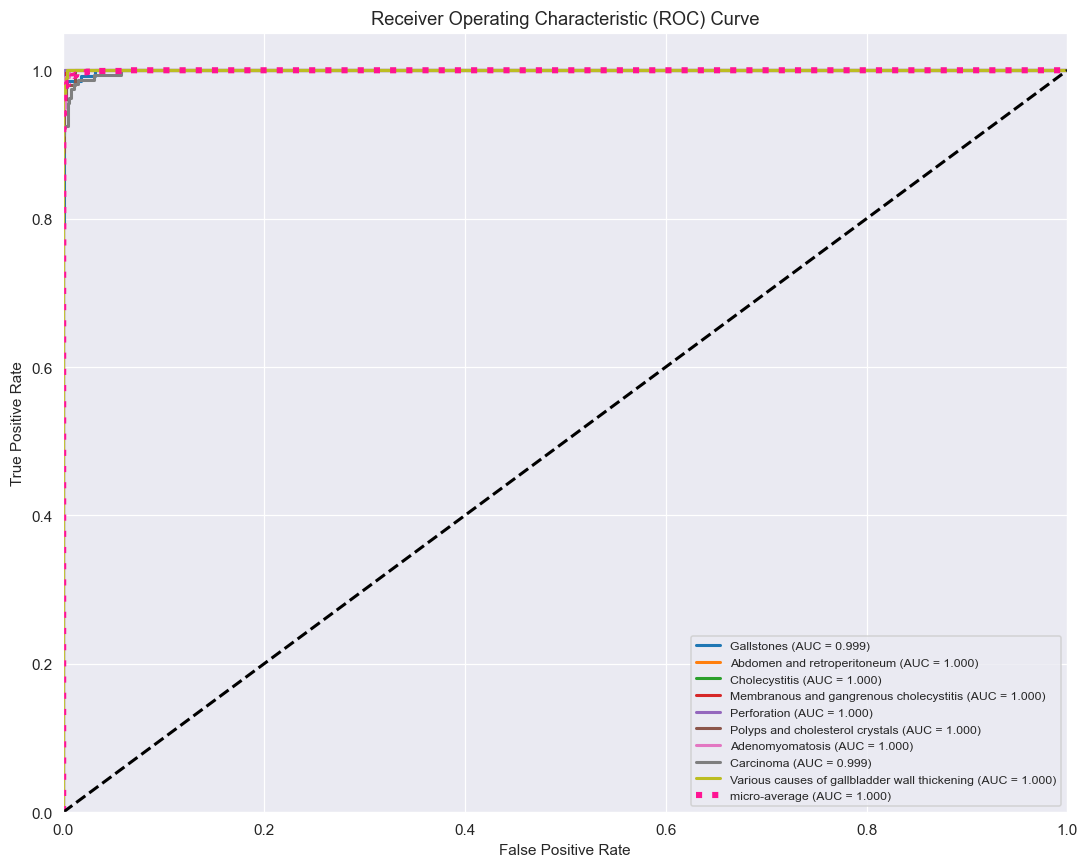

Per-class AUC:
  Gallstones                                      0.9994
  Abdomen and retroperitoneum                     1.0000
  Cholecystitis                                   1.0000
  Membranous and gangrenous cholecystitis         1.0000
  Perforation                                     1.0000
  Polyps and cholesterol crystals                 0.9996
  Adenomyomatosis                                 0.9999
  Carcinoma                                       0.9990
  Various causes of gallbladder wall thickening   0.9999

Micro-average AUC: 0.9997
Macro-average AUC: 0.9997


In [17]:
# ---------------------------------------------------------------------------------
# ROC curves (one-vs-rest) and AUC scores
# ---------------------------------------------------------------------------------
y_bin = label_binarize(y_true, classes=range(N_CLASSES))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(N_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], test_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), test_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 8))
colors = [plt.get_cmap("tab10")(i % 10) for i in range(N_CLASSES)]
for i, color in zip(range(N_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"{DISPLAY[i]} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", ls=":", lw=4,
         label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / "roc_curve.png", dpi=200); plt.show()

print("Per-class AUC:")
for i in range(N_CLASSES):
    print(f"  {DISPLAY[i]:<48}{roc_auc_score(y_bin[:, i], test_probs[:, i]):.4f}")
print(f"\nMicro-average AUC: {roc_auc_score(y_bin, test_probs, average='micro'):.4f}")
print(f"Macro-average AUC: {roc_auc_score(y_bin, test_probs, average='macro'):.4f}")

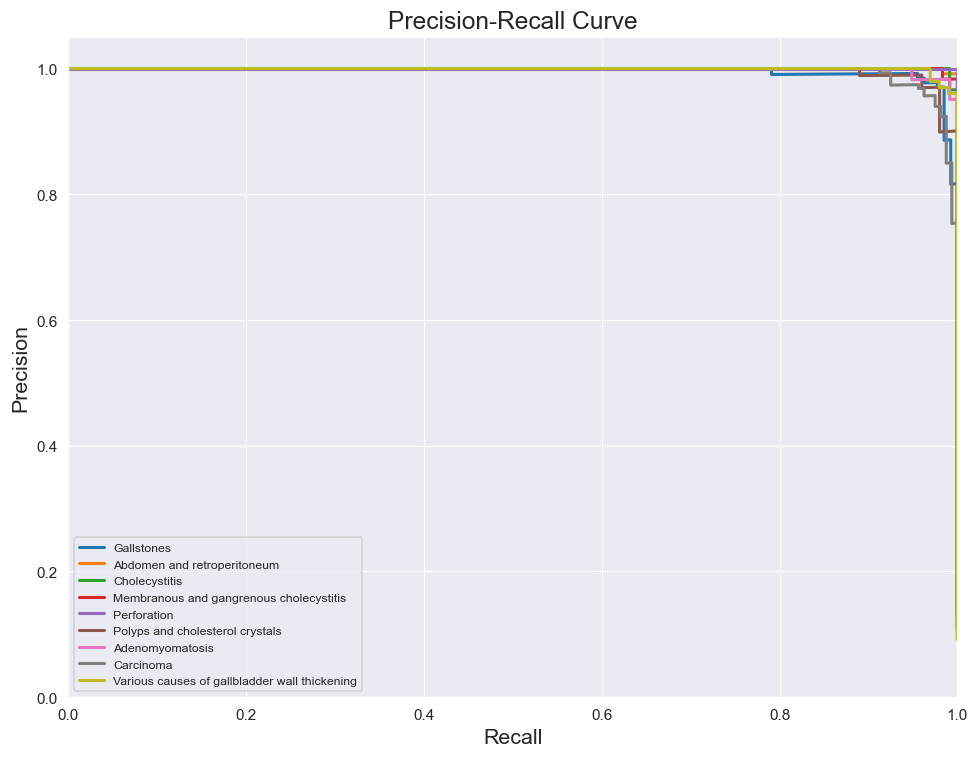

In [18]:
# ---------------------------------------------------------------------------------
# Precision-Recall curves
# ---------------------------------------------------------------------------------
plt.figure(figsize=(9, 7))
for i, color in zip(range(N_CLASSES), colors):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], test_probs[:, i])
    plt.plot(rec, prec, color=color, lw=2, label=DISPLAY[i])
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("Recall", fontsize=14); plt.ylabel("Precision", fontsize=14)
plt.title("Precision-Recall Curve", fontsize=16)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / "pr_curve.png", dpi=200); plt.show()

## 6. Visualizations and Sample Predictions

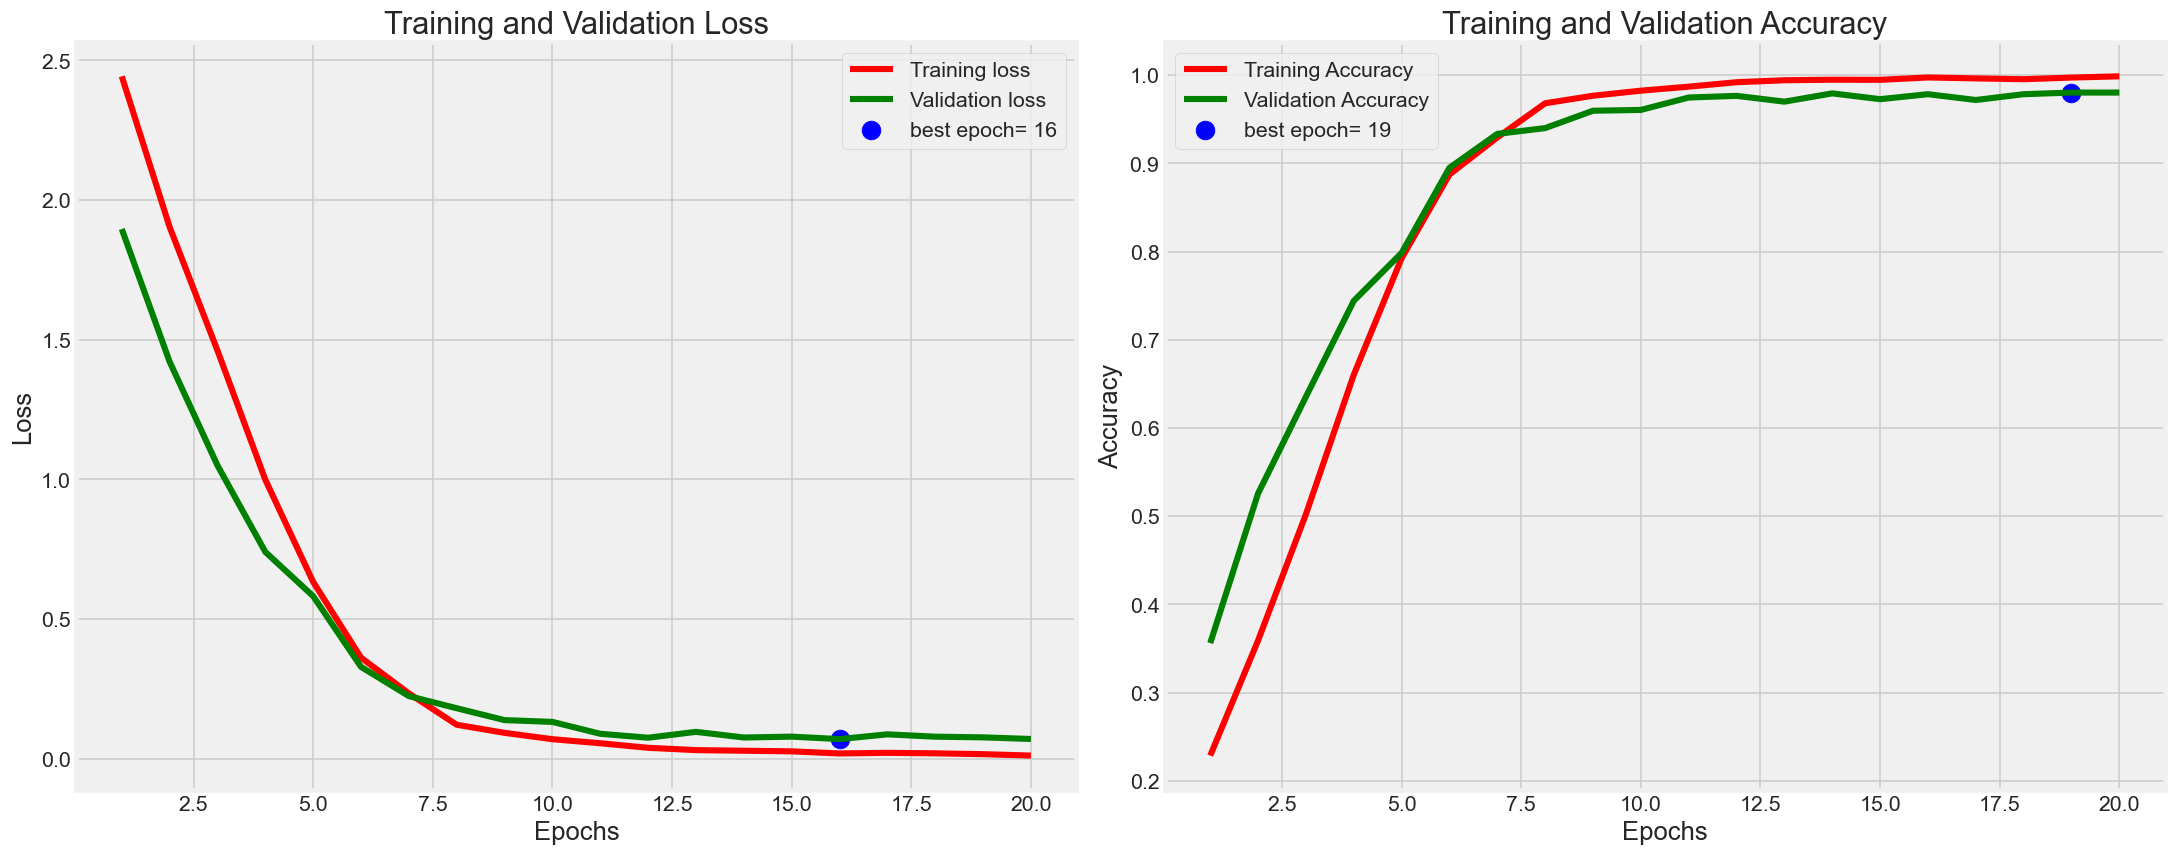

Lowest validation loss    : 0.0696 at epoch 16
Highest validation accuracy: 0.9803 at epoch 19


In [19]:
# ---------------------------------------------------------------------------------
# Training vs validation loss and accuracy
# ---------------------------------------------------------------------------------
tr_acc_h, tr_loss_h = history["accuracy"], history["loss"]
val_acc_h, val_loss_h = history["val_accuracy"], history["val_loss"]

index_loss = int(np.argmin(val_loss_h)); val_lowest = val_loss_h[index_loss]
index_acc  = int(np.argmax(val_acc_h));  acc_highest = val_acc_h[index_acc]
Epochs = list(range(1, len(tr_acc_h) + 1))

plt.figure(figsize=(20, 8))
plt.style.use("fivethirtyeight")

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss_h, "r", label="Training loss")
plt.plot(Epochs, val_loss_h, "g", label="Validation loss")
plt.scatter(index_loss + 1, val_lowest, s=150, c="blue", label=f"best epoch= {index_loss + 1}")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc_h, "r", label="Training Accuracy")
plt.plot(Epochs, val_acc_h, "g", label="Validation Accuracy")
plt.scatter(index_acc + 1, acc_highest, s=150, c="blue", label=f"best epoch= {index_acc + 1}")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "training_validation_plots.png", dpi=200)
plt.show()
plt.style.use("default"); sns.set_style("darkgrid")

print(f"Lowest validation loss    : {val_lowest:.4f} at epoch {index_loss + 1}")
print(f"Highest validation accuracy: {acc_highest:.4f} at epoch {index_acc + 1}")

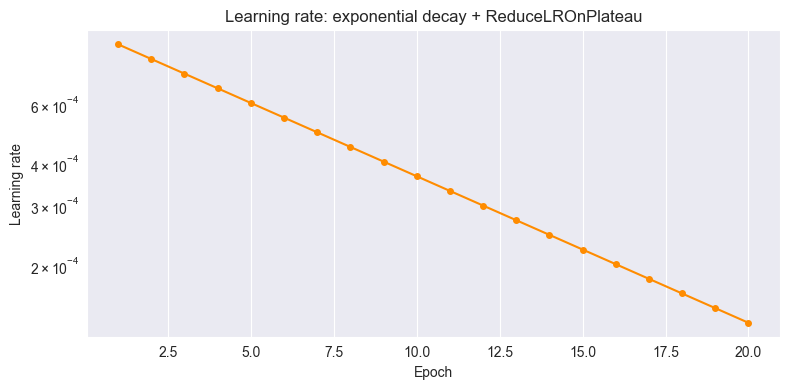

In [20]:
# ---------------------------------------------------------------------------------
# Learning-rate schedule actually used during training
# ---------------------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(Epochs, history["lr"], "o-", color="darkorange", ms=4)
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Learning rate")
plt.title("Learning rate: exponential decay + ReduceLROnPlateau")
plt.tight_layout(); plt.show()

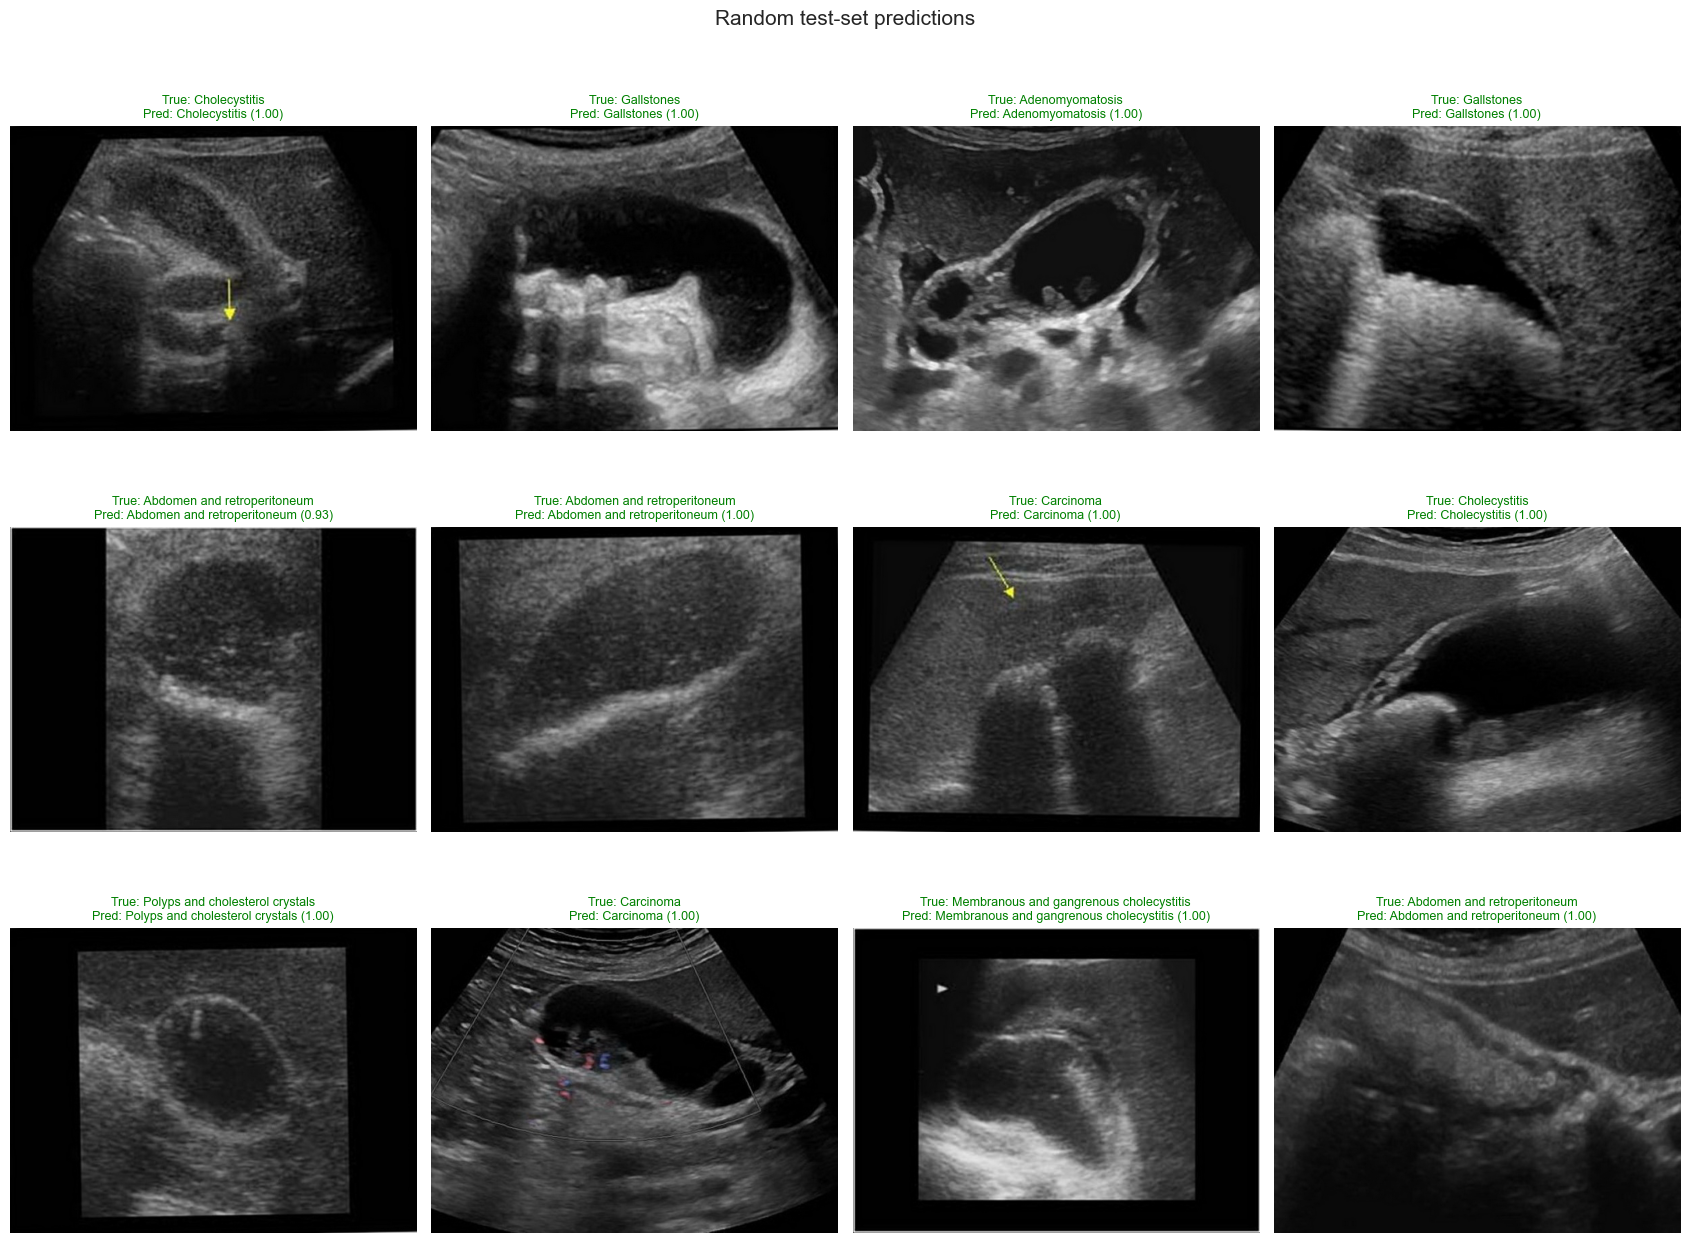

In [21]:
# ---------------------------------------------------------------------------------
# Sample predictions on the test set (green = correct, red = misclassified)
# ---------------------------------------------------------------------------------
rng = np.random.default_rng(SEED)
idxs = rng.choice(len(test_df), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(17, 13))
for ax, i in zip(axes.ravel(), idxs):
    img = Image.open(test_df["image"].iloc[i]).convert("RGB")
    t_name = DISPLAY[int(y_true[i])]
    p_name = DISPLAY[int(y_pred[i])]
    conf = test_probs[i].max()
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"True: {t_name}\nPred: {p_name} ({conf:.2f})",
                 fontsize=9, color=("green" if t_name == p_name else "red"))
plt.suptitle("Random test-set predictions", fontsize=15, y=1.002)
plt.tight_layout(); plt.show()

Misclassified: 23 / 1071 (2.15%)



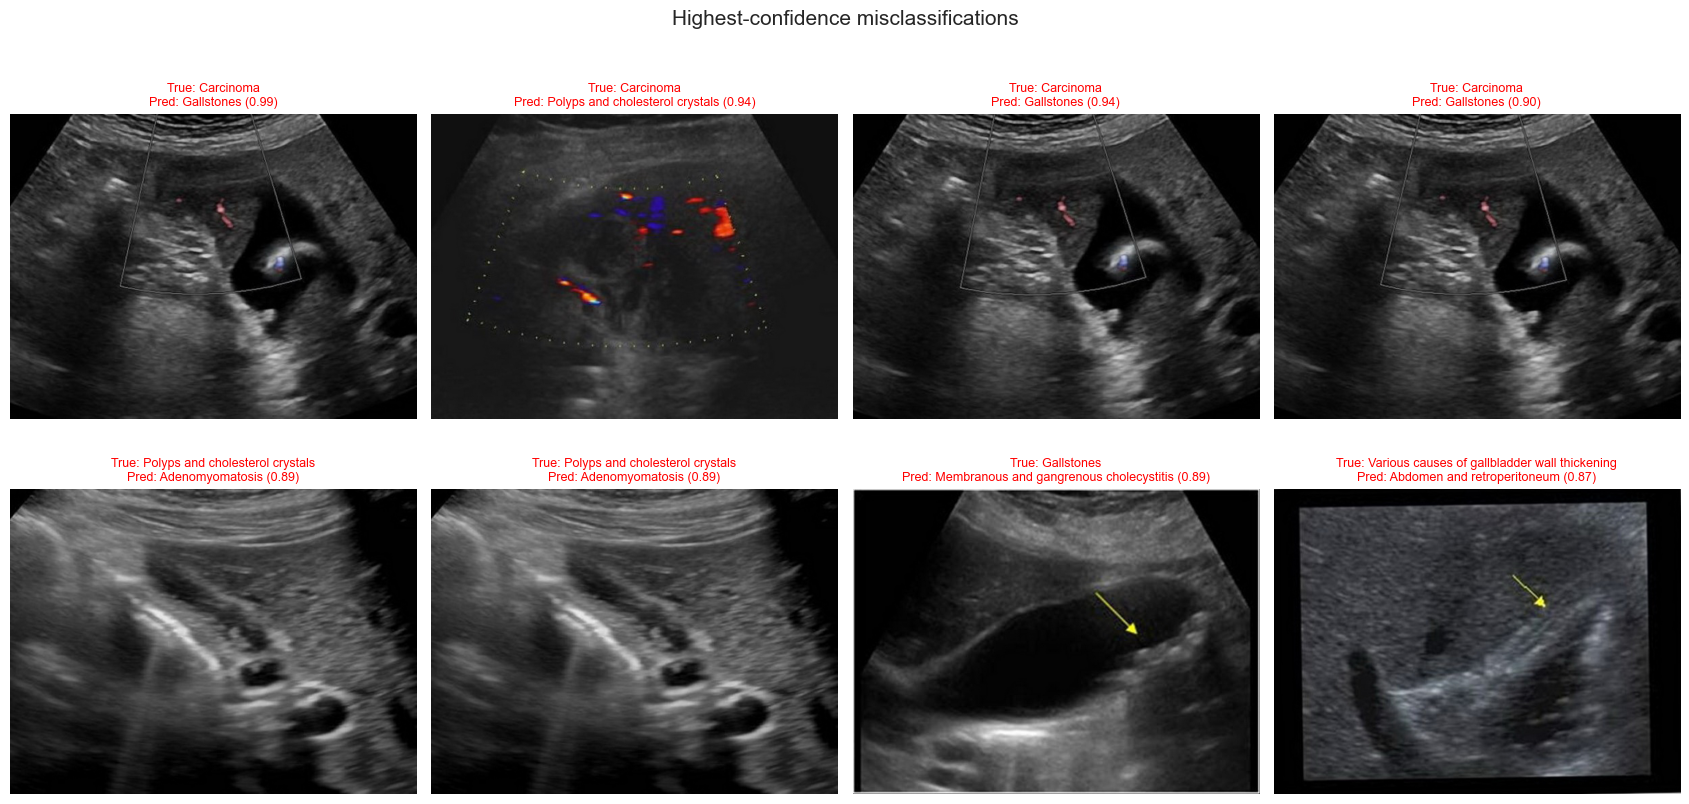

Top confused pairs (true -> predicted, count):
  Polyps and cholesterol crystals  ->  Adenomyomatosis  : 4
  Carcinoma  ->  Gallstones  : 4
  Gallstones  ->  Membranous and gangrenous cholecystitis  : 2
  Carcinoma  ->  Cholecystitis  : 2
  Carcinoma  ->  Adenomyomatosis  : 2
  Carcinoma  ->  Various causes of gallbladder wall thickening  : 2
  Cholecystitis  ->  Gallstones  : 1
  Perforation  ->  Abdomen and retroperitoneum  : 1
  Carcinoma  ->  Membranous and gangrenous cholecystitis  : 1
  Carcinoma  ->  Polyps and cholesterol crystals  : 1


In [22]:
# ---------------------------------------------------------------------------------
# Misclassified examples and the most frequently confused class pairs
# ---------------------------------------------------------------------------------
wrong = np.where(y_pred != y_true)[0]
print(f"Misclassified: {len(wrong)} / {len(y_true)} ({100 * len(wrong) / len(y_true):.2f}%)\n")

if len(wrong) > 0:
    order = wrong[np.argsort(-test_probs[wrong].max(1))][:8]
    fig, axes = plt.subplots(2, 4, figsize=(17, 8.5))
    for ax, i in zip(axes.ravel(), order):
        ax.imshow(Image.open(test_df["image"].iloc[i]).convert("RGB")); ax.axis("off")
        ax.set_title(f"True: {DISPLAY[int(y_true[i])]}\n"
                     f"Pred: {DISPLAY[int(y_pred[i])]} ({test_probs[i].max():.2f})",
                     fontsize=9, color="red")
    for ax in axes.ravel()[len(order):]:
        ax.axis("off")
    plt.suptitle("Highest-confidence misclassifications", fontsize=15, y=1.003)
    plt.tight_layout(); plt.show()

    pairs = sorted([(DISPLAY[t], DISPLAY[p], int(cm[t, p]))
                    for t in range(N_CLASSES) for p in range(N_CLASSES)
                    if t != p and cm[t, p] > 0], key=lambda z: -z[2])[:10]
    print("Top confused pairs (true -> predicted, count):")
    for t, p, c in pairs:
        print(f"  {t}  ->  {p}  : {c}")

In [23]:
# ---------------------------------------------------------------------------------
# Final summary + save the trained model
# ---------------------------------------------------------------------------------
summary = pd.Series({
    "Task":                  "9-class gallbladder disease classification (ultrasound)",
    "Architecture":          "Residual Attention CNN (3 residual blocks + channel attention)",
    "Trainable parameters":  f"{n_params:,}",
    "Input":                 f"{CHANNELS} x {IMG_SIZE} x {IMG_SIZE}, rescaled to [0,1], no augmentation",
    "Split (train/val/test)": f"{len(train_df)} / {len(valid_df)} / {len(test_df)}",
    "Optimiser":             f"Adamax (lr={LR}) + exp decay + ReduceLROnPlateau",
    "Loss":                  f"Cross-entropy + L2({L2_LAMBDA}) on dense layers",
    "Epochs":                f"{len(tr_acc_h)}",
    "Train accuracy":        f"{train_acc:.4f}",
    "Validation accuracy":   f"{valid_acc:.4f}",
    "Test accuracy":         f"{test_acc:.4f}",
    "Test macro F1":         f"{report['macro avg']['f1-score']:.4f}",
    "Test macro AUC":        f"{roc_auc_score(y_bin, test_probs, average='macro'):.4f}",
}, name="value").to_frame()

pd.set_option("display.max_colwidth", 90)
print(summary.to_string())

torch.save({"state_dict": model.state_dict(), "classes": CLASSES,
            "display_names": DISPLAY, "img_size": IMG_SIZE},
           OUT_DIR / "gallbladder_resattn_cnn.pt")
print(f"\nModel saved to: {(OUT_DIR / 'gallbladder_resattn_cnn.pt').resolve()}")

                                                                                 value
Task                           9-class gallbladder disease classification (ultrasound)
Architecture            Residual Attention CNN (3 residual blocks + channel attention)
Trainable parameters                                                         2,709,353
Input                                3 x 100 x 100, rescaled to [0,1], no augmentation
Split (train/val/test)                                              8554 / 1067 / 1071
Optimiser                            Adamax (lr=0.001) + exp decay + ReduceLROnPlateau
Loss                                        Cross-entropy + L2(0.0001) on dense layers
Epochs                                                                              20
Train accuracy                                                                  0.9999
Validation accuracy                                                             0.9803
Test accuracy                              